Dependencies are managed in requirements.txt.

Install once in your environment before running this notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

from pathlib import Path

from arch import arch_model

import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
from statsmodels.graphics.tsaplots import plot_acf

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from scipy.stats import spearmanr

# Yield Curve Regimes and Sector ETF Return Predictability
---

## Section 1: Data Collection and Cleaning

This section pulls and cleans two datasets:
1. U.S. Treasury yields across 10 maturities from FRED (Jan 2010 – present)
2. Sector ETF prices for 8 SPDR sector funds from Yahoo Finance

The goal is to produce two aligned monthly dataframes: one capturing yield curve shape at each month-end, and one capturing the forward (next-month) return for each sector ETF. The forward return is the dependent variable in Section 5.

### 1.1: Yield Curve Data (FRED)

The FRED yield data is pre-downloaded into `data/fred_yields_daily.csv` using the `download_data.py` utility script. This notebook reads that local file so the analysis can run without network access.

Missing value treatment: FRED yield series report `NaN` on weekends, federal holidays, and occasional data gaps. We forward-fill these gaps, which is the standard practice for yield data. Any row where more than 2 maturities are simultaneously missing even after forward-filling is dropped too.

In [2]:
YIELD_SERIES = ['DGS1MO', 'DGS3MO', 'DGS6MO', 'DGS1', 'DGS2', 'DGS5', 'DGS7', 'DGS10', 'DGS20', 'DGS30']

DATA_DIR = Path('data')
YIELDS_PATH = DATA_DIR / 'fred_yields_daily.csv'

yields_raw = pd.read_csv(
    YIELDS_PATH,
    index_col=0,
    parse_dates=True,
)
yields_raw = yields_raw[YIELD_SERIES]  # enforce expected columns and order
print(f"Raw yield data: {yields_raw.shape[0]} observations, {yields_raw.shape[1]} maturities")
yields_raw.tail(3)

Raw yield data: 4252 observations, 10 maturities


,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2,DGS5,DGS7,DGS10,DGS20,DGS30
DATE,,,,,,,,,,
2026-04-16,3.69,3.70,3.71,3.69,3.78,3.91,4.10,4.32,4.90,4.93
2026-04-17,3.69,3.70,3.69,3.64,3.71,3.84,4.04,4.26,4.85,4.88
2026-04-20,3.69,3.71,3.72,3.65,3.72,3.86,4.04,4.26,4.85,4.88


In [3]:
yields_daily = yields_raw.ffill()  # fill weekend/holiday gaps with last known yield
# drop initial rows before any data appears (pre-data rows have all maturities as NaN)
yields_daily = yields_daily.dropna()

print(f"Clean yield data: {yields_daily.shape[0]} observations")
print(f"Date range: {yields_daily.index.min().date()} to {yields_daily.index.max().date()}")
yields_daily.tail(3)

Clean yield data: 4251 observations
Date range: 2010-01-04 to 2026-04-20


,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2,DGS5,DGS7,DGS10,DGS20,DGS30
DATE,,,,,,,,,,
2026-04-16,3.69,3.70,3.71,3.69,3.78,3.91,4.10,4.32,4.90,4.93
2026-04-17,3.69,3.70,3.69,3.64,3.71,3.84,4.04,4.26,4.85,4.88
2026-04-20,3.69,3.71,3.72,3.65,3.72,3.86,4.04,4.26,4.85,4.88


### 1.2: Sector ETF Data (Yahoo Finance)

The ETF adjusted close data is pre-downloaded into `data/sector_etf_prices_daily.csv` using the `download_data.py` utility script. This notebook reads that local file so the analysis can run without network access.

From daily prices we compute two return series:
- Daily log returns: `log(P_t / P_{t-1})` (used for volatility analysis)
- Monthly forward returns: the log return over the next calendar month

Forward returns are constructed by first resampling daily log returns to monthly sums, then shifting back by one period so that the value at month t represents the return earned during month t+1. This is the correct temporal alignment to avoid lookahead bias: we use month t yield curve data to predict month t+1 returns.

In [4]:
ETF_TICKERS = ['XLK', 'XLF', 'XLE', 'XLU', 'XLV', 'XLI', 'XLP', 'XLY']

ETF_PRICES_PATH = DATA_DIR / 'sector_etf_prices_daily.csv'

etf_prices = pd.read_csv(
    ETF_PRICES_PATH,
    index_col=0,
    parse_dates=True,
)
etf_prices = etf_prices[ETF_TICKERS]  # enforce expected columns and order

print(f"ETF prices: {etf_prices.shape[0]} observations, {etf_prices.shape[1]} tickers")
etf_prices.tail(3)

ETF prices: 4099 observations, 8 tickers


,XLK,XLF,XLE,XLU,XLV,XLI,XLP,XLY
Date,,,,,,,,
2026-04-17,154.350006,52.430000,55.020000,46.160000,148.800003,173.509995,82.459999,120.410004
2026-04-20,154.559998,52.630001,55.070000,45.750000,147.419998,173.899994,82.389999,119.870003
2026-04-21,154.690002,52.299999,55.869999,44.950001,145.919998,171.440002,81.839996,118.970001


In [5]:
etf_daily_returns = np.log(etf_prices / etf_prices.shift(1)).dropna(how='all')

# monthly log return is the sum of daily log returns within each month-end bucket
etf_monthly_returns = etf_daily_returns.resample('ME').sum()

# month t holds next month's return (so month-t yields predict month-(t+1) returns)
etf_monthly_forward = etf_monthly_returns.shift(-1)

print(f"Daily log returns:        {etf_daily_returns.shape}")
print(f"Monthly returns:          {etf_monthly_returns.shape}")
print(f"Monthly forward returns:  {etf_monthly_forward.shape}")
etf_monthly_forward.tail(3)

Daily log returns:        (4098, 8)
Monthly returns:          (196, 8)
Monthly forward returns:  (196, 8)


,XLK,XLF,XLE,XLU,XLV,XLI,XLP,XLY
Date,,,,,,,,
2026-02-28,-0.041906,-0.035752,0.097717,-0.032346,-0.084544,-0.088206,-0.087832,-0.067805
2026-03-31,0.151826,0.057653,-0.092100,-0.020696,-0.004717,0.058305,-0.001709,0.087707
2026-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.3: Alignment

To combine yield curve data with ETF forward returns in a single regression framework, both must share the same monthly date index. We resample the daily yield curve to month-end observations (last available yield of each month) and then intersect the two date indices.

The intersection drops any months present in one dataset but not the other (e.g. typically only the final incomplete month, since forward returns for it cannot be computed).

In [6]:
yields_monthly = yields_daily.resample('ME').last()
common_idx = yields_monthly.index.intersection(etf_monthly_forward.dropna(how='all').index)

yields_monthly = yields_monthly.loc[common_idx]
etf_forward_aligned = etf_monthly_forward.loc[common_idx]

assert yields_monthly.index.equals(etf_forward_aligned.index), "Date indices do not match!"

print(f"Aligned dataset: {len(yields_monthly)} monthly observations")
print(f"Date range: {yields_monthly.index.min().date()} to {yields_monthly.index.max().date()}")
print(f"\nYield curve columns: {list(yields_monthly.columns)}")
print(f"ETF columns:         {list(etf_forward_aligned.columns)}")

Aligned dataset: 195 monthly observations
Date range: 2010-01-31 to 2026-03-31

Yield curve columns: ['DGS1MO', 'DGS3MO', 'DGS6MO', 'DGS1', 'DGS2', 'DGS5', 'DGS7', 'DGS10', 'DGS20', 'DGS30']
ETF columns:         ['XLK', 'XLF', 'XLE', 'XLU', 'XLV', 'XLI', 'XLP', 'XLY']


In [7]:
print("Yield curve snapshot (last 3 months):")
display(yields_monthly.tail(3).round(3))
print("\nForward ETF returns snapshot (last 3 months):")
display(etf_forward_aligned.tail(3).round(4))

Yield curve snapshot (last 3 months):


,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2,DGS5,DGS7,DGS10,DGS20,DGS30
2026-01-31,3.72,3.67,3.61,3.48,3.52,3.79,4.01,4.26,4.82,4.87
2026-02-28,3.74,3.67,3.60,3.48,3.38,3.51,3.72,3.97,4.57,4.64
2026-03-31,3.74,3.70,3.72,3.68,3.79,3.92,4.11,4.30,4.88,4.88



Forward ETF returns snapshot (last 3 months):


,XLK,XLF,XLE,XLU,XLV,XLI,XLP,XLY
2026-01-31,-0.0362,-0.0383,0.0911,0.0986,0.0347,0.0683,0.0750,-0.0362
2026-02-28,-0.0419,-0.0358,0.0977,-0.0323,-0.0845,-0.0882,-0.0878,-0.0678
2026-03-31,0.1518,0.0577,-0.0921,-0.0207,-0.0047,0.0583,-0.0017,0.0877


---

## Section 2: Exploratory Data Analysis

Before building models, we visualize the raw data to build intuition about yield curve behavior across different rate environments and how sector ETF volatility and correlations vary over time. This section produces four visualizations and two statistical summaries that motivate the regime-based modeling approach shown in future sections.

### 2.1: Yield Curve Shapes at Key Dates

Plotting the full yield curve (yield vs. maturity) at six economically distinct dates reveals how the curve's shape transformed across rate regimes. The March 2020 COVID shock shows steep curvature from emergency Fed cuts collapsing short-end yields while long-end yields moved less. October 2022 shows a deeply inverted curve during the most aggressive hiking cycle in decades, with short rates well above long rates. 

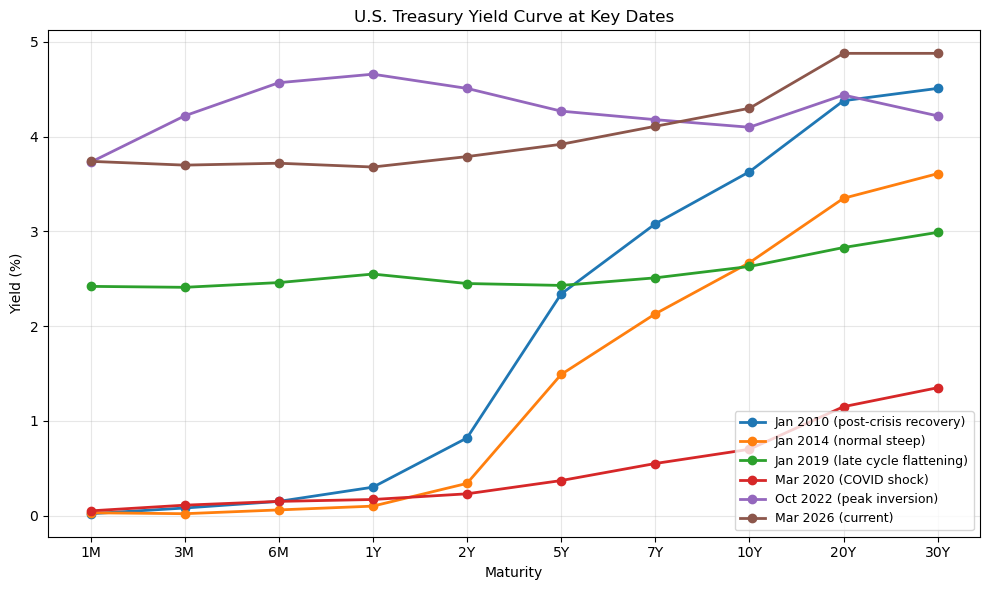

In [8]:
KEY_DATES = ['2010-01-31', '2014-01-31', '2019-01-31', '2020-03-31', '2022-10-31',
             str(yields_monthly.index[-1].date())]
KEY_LABELS = ['Jan 2010 (post-crisis recovery)', 'Jan 2014 (normal steep)',
              'Jan 2019 (late cycle flattening)', 'Mar 2020 (COVID shock)',
              'Oct 2022 (peak inversion)',
              yields_monthly.index[-1].strftime('%b %Y') + ' (current)']
MATURITIES = ['1M', '3M', '6M', '1Y', '2Y', '5Y', '7Y', '10Y', '20Y', '30Y']

fig, ax = plt.subplots(figsize=(10, 6))
for date, label in zip(KEY_DATES, KEY_LABELS):
    ts = pd.Timestamp(date)
    # yields_monthly is month-end indexed; pick the last available month-end on/before ts
    idx = yields_monthly.index[yields_monthly.index <= ts]
    if len(idx) == 0:
        raise ValueError(f"No yields_monthly rows on/before {ts.date()}")
    row = yields_monthly.loc[idx[-1]]
    ax.plot(MATURITIES, row.values, marker='o', label=label, linewidth=2)

ax.set_title('U.S. Treasury Yield Curve at Key Dates')
ax.set_xlabel('Maturity')
ax.set_ylabel('Yield (%)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 2.2: 2Y10Y Spread Over Time

The spread between the 10-year and 2-year Treasury yield is the most widely monitored slope indicator in fixed income markets. When short-term rates exceed long-term rates (spread < 0), the curve inverts, historically preceding economic slowdowns. Red shading marks inversion periods. This sets up the regime classification in Section 3.

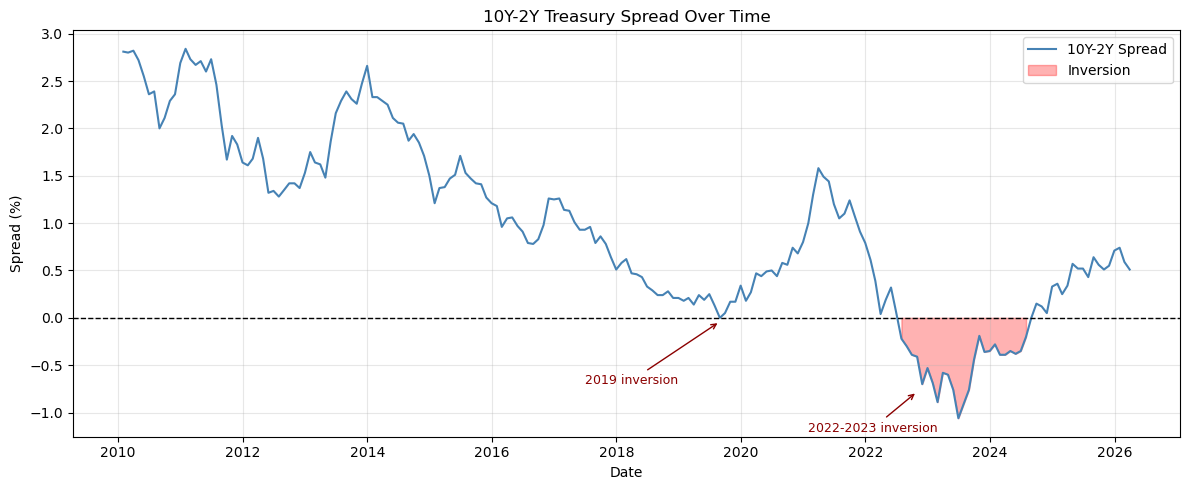

In [9]:
spread = yields_monthly['DGS10'] - yields_monthly['DGS2']

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(spread.index, spread.values, color='steelblue', linewidth=1.5, label='10Y-2Y Spread')
ax.fill_between(spread.index, spread.values, 0, where=(spread < 0),
                color='red', alpha=0.3, label='Inversion')
ax.axhline(0, color='black', linestyle='--', linewidth=1)

ax.annotate('2019 inversion', xy=(pd.Timestamp('2019-08-31'), -0.04),
            xytext=(pd.Timestamp('2017-06-30'), -0.7),
            arrowprops=dict(arrowstyle='->', color='darkred'), color='darkred', fontsize=9)
ax.annotate('2022-2023 inversion', xy=(pd.Timestamp('2022-10-31'), -0.78),
            xytext=(pd.Timestamp('2021-01-31'), -1.2),
            arrowprops=dict(arrowstyle='->', color='darkred'), color='darkred', fontsize=9)

ax.set_title('10Y-2Y Treasury Spread Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Spread (%)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 2.3: Rolling Volatility of Sector ETFs

The 60-day rolling standard deviation of daily log returns, annualized by multiplying by sqrt(252), captures how risk evolved over time across sectors. COVID (March 2020) and the 2022 rate shock are the two largest volatility spikes visible across all sectors. Energy (XLE) shows the most persistent elevated volatility due to commodity price cycles compounding equity market risk, making it the natural candidate for the GARCH extension below.

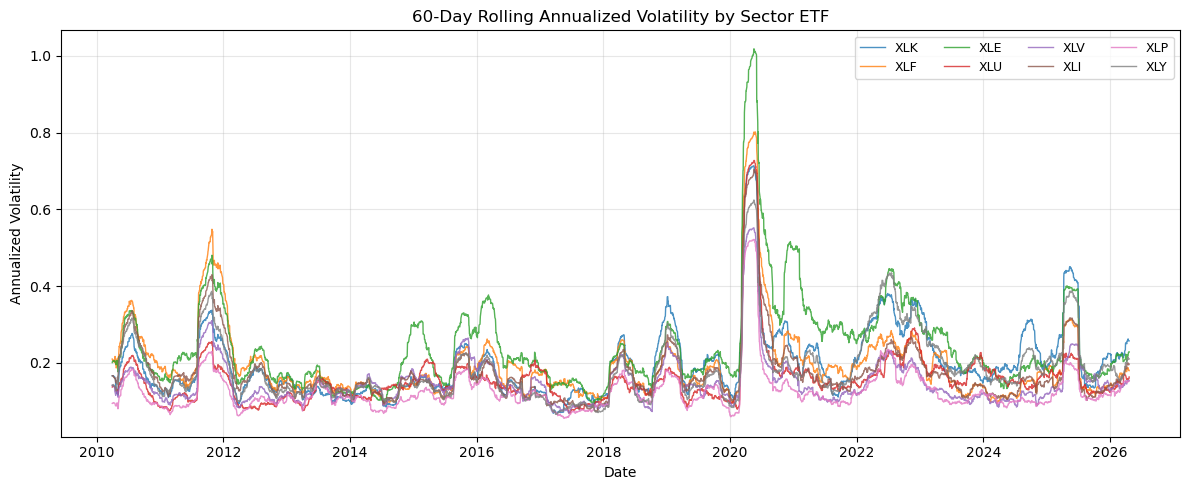

In [10]:
rolling_vol = etf_daily_returns.rolling(60).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(12, 5))
for ticker in ETF_TICKERS:
    ax.plot(rolling_vol.index, rolling_vol[ticker], linewidth=1, alpha=0.8, label=ticker)

ax.set_title('60-Day Rolling Annualized Volatility by Sector ETF')
ax.set_xlabel('Date')
ax.set_ylabel('Annualized Volatility')
ax.legend(ncol=4, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### GARCH(1,1) Extension: Conditional Volatility for XLE

Fit a GARCH(1,1) model to XLE daily returns. Unlike rolling standard deviation, which weights all observations equally within the window, GARCH estimates a conditional variance that decays based on recent shocks and recent variance. This produces a more responsive measure of current risk, especially for assets with strong volatility clustering like XLE.

Returns are multiplied by 100 before fitting to improve numerical stability, then converted back to decimal after.

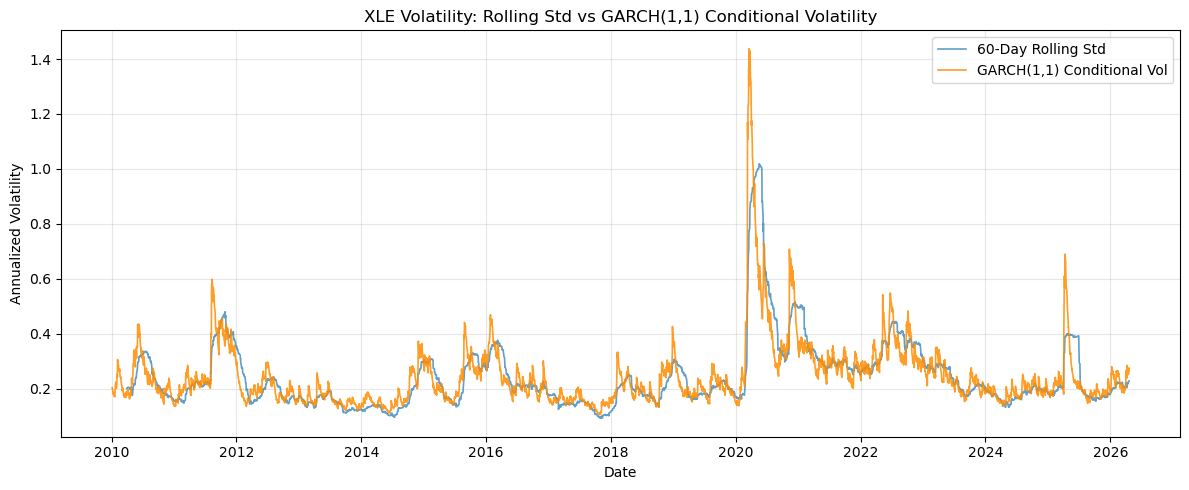

In [11]:
xle_pct = etf_daily_returns['XLE'] * 100
garch_res = arch_model(xle_pct, vol='Garch', p=1, q=1).fit(disp='off')
cond_vol = garch_res.conditional_volatility * np.sqrt(252) / 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(rolling_vol.index, rolling_vol['XLE'], label='60-Day Rolling Std', alpha=0.7, linewidth=1.2)
ax.plot(cond_vol.index, cond_vol.values, label='GARCH(1,1) Conditional Vol',
        alpha=0.85, linewidth=1.2, color='darkorange')
ax.set_title('XLE Volatility: Rolling Std vs GARCH(1,1) Conditional Volatility')
ax.set_xlabel('Date')
ax.set_ylabel('Annualized Volatility')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 2.4: Sector Return Correlation Heatmap by Regime

We preview the regime classification formalized in Section 3 to examine how sector correlations shift across yield curve environments. Regimes are assigned using the 2Y10Y spread: normal (spread > +0.50%), flat (between +-0.50%), inverted (spread < -0.50%). During inversion regimes, macro uncertainty tends to dominate sector fundamentals, pushing correlations higher and reducing the diversification benefit of holding multiple sectors.

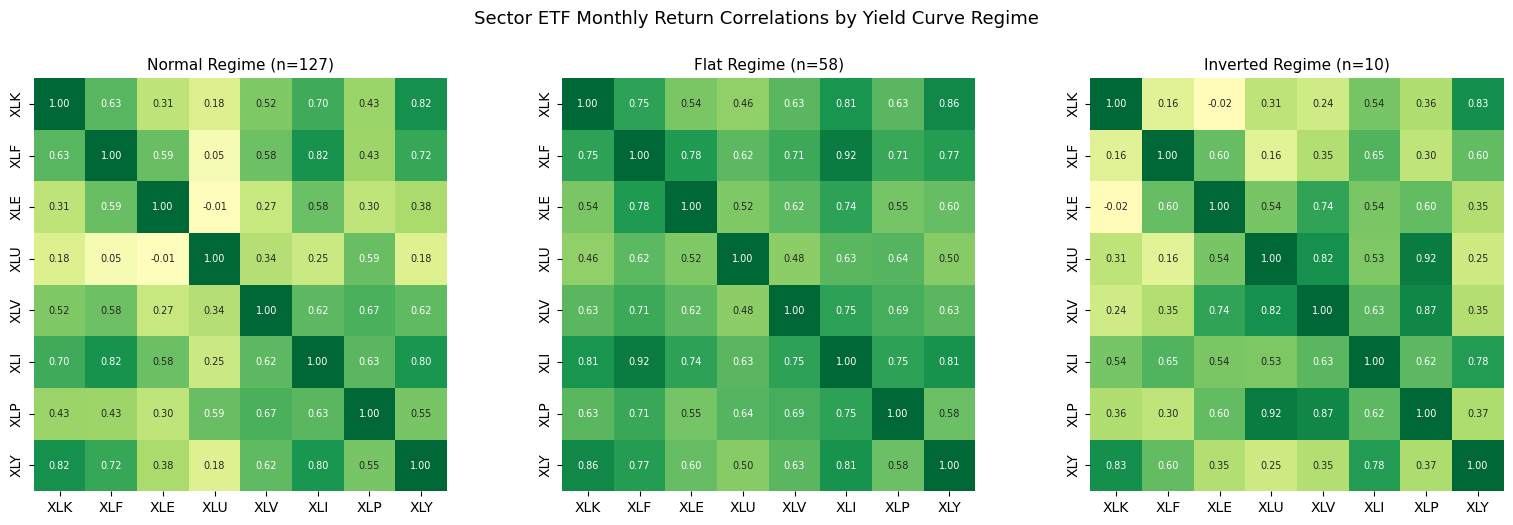

In [12]:
regimes = pd.cut(spread, bins=[-np.inf, -0.5, 0.5, np.inf], labels=['Inverted', 'Flat', 'Normal'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, regime in zip(axes, ['Normal', 'Flat', 'Inverted']):
    mask = regimes == regime
    corr = etf_forward_aligned.loc[mask].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
                vmin=-1, vmax=1, ax=ax, cbar=False, square=True, annot_kws={'size': 7})
    ax.set_title(f'{regime} Regime (n={mask.sum()})', fontsize=11)

fig.suptitle('Sector ETF Monthly Return Correlations by Yield Curve Regime', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 2.5: Additional EDA Statistics

Two supporting statistics complete the EDA.

Autocorrelation of the 2Y10Y Spread (12 Lags): The spread is highly persistent, confirming that regime transitions are gradual. This validates using monthly snapshots as regime labels since the regime at month t provides real information about what regime month t+1 will be in.

Summary Statistics by Regime: Mean, standard deviation, skewness, and kurtosis of monthly ETF returns split by regime provide a first-pass view of how return distributions shift across yield curve environments.

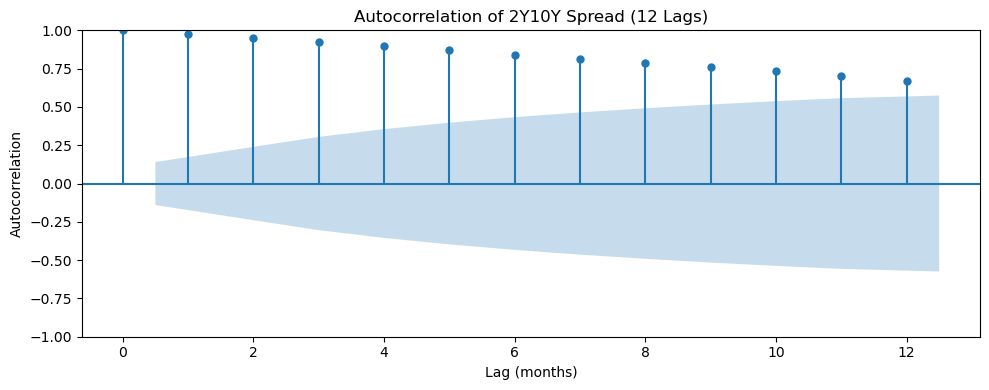

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(spread.dropna(), lags=12, ax=ax, alpha=0.05)
ax.set_title('Autocorrelation of 2Y10Y Spread (12 Lags)')
ax.set_xlabel('Lag (months)')
ax.set_ylabel('Autocorrelation')
plt.tight_layout()
plt.show()

In [14]:
stats_rows = []
for regime in ['Normal', 'Flat', 'Inverted']:
    for ticker in ETF_TICKERS:
        s = etf_forward_aligned.loc[regimes == regime, ticker].dropna()
        stats_rows.append({'Regime': regime, 'Ticker': ticker,
                           'Mean': s.mean(), 'Std': s.std(),
                           'Skew': s.skew(), 'Kurtosis': s.kurtosis()})

pd.DataFrame(stats_rows).set_index(['Regime', 'Ticker']).round(4)

Mean     Std    Skew  Kurtosis
Regime   Ticker                                  
Normal   XLK     0.0150  0.0440  0.1541   -0.0377
         XLF     0.0120  0.0482 -0.0849    0.6077
         XLE     0.0116  0.0660  0.2854    1.4074
         XLU     0.0095  0.0375 -0.2592    0.0373
         XLV     0.0103  0.0370 -0.3711    0.0758
         XLI     0.0135  0.0446 -0.0005    0.5561
         XLP     0.0087  0.0333 -0.0348    0.1226
         XLY     0.0134  0.0420 -0.1243    0.2329
Flat     XLK     0.0139  0.0626 -0.4446   -0.3668
         XLF     0.0060  0.0645 -1.1542    2.3939
         XLE    -0.0044  0.1006 -0.9287    4.9699
         XLU     0.0109  0.0465 -0.8600    0.8231
         XLV     0.0099  0.0449 -0.1768   -0.3171
         XLI     0.0070  0.0645 -0.8183    1.0116
         XLP     0.0096  0.0380 -0.7900    0.7390
         XLY     0.0086  0.0681 -0.1353    0.3390
Inverted XLK     0.0196  0.0650 -0.3128   -1.0107
         XLF    -0.0070  0.0561 -0.0118   -1.0671
         XLE     0.0028  0.0574 -0.7769    0.0058
         XLU    -0.0161  0.0423  0.0885   -1.7463
         XLV    -0.0061  0.0311  0.2014   -1.3034
         XLI     0.0014  0.0470  1.2096    2.0719
         XLP    -0.0089  0.0379  0.0602   -1.6196
         XLY     0.0106  0.0766  0.2224    0.2858

---

## Section 3: Regime Classification

Yield curve regimes are defined using the 2Y10Y spread (DGS10 minus DGS2) with fixed thresholds:

- Normal: spread > +0.50%
- Flat: spread between -0.50% and +0.50%
- Inverted: spread <= −0.50%

These labels are assigned to each month-end observation and appended to the main dataframe. The visualization below overlays colored background bands on the spread time series to show when each regime was active.

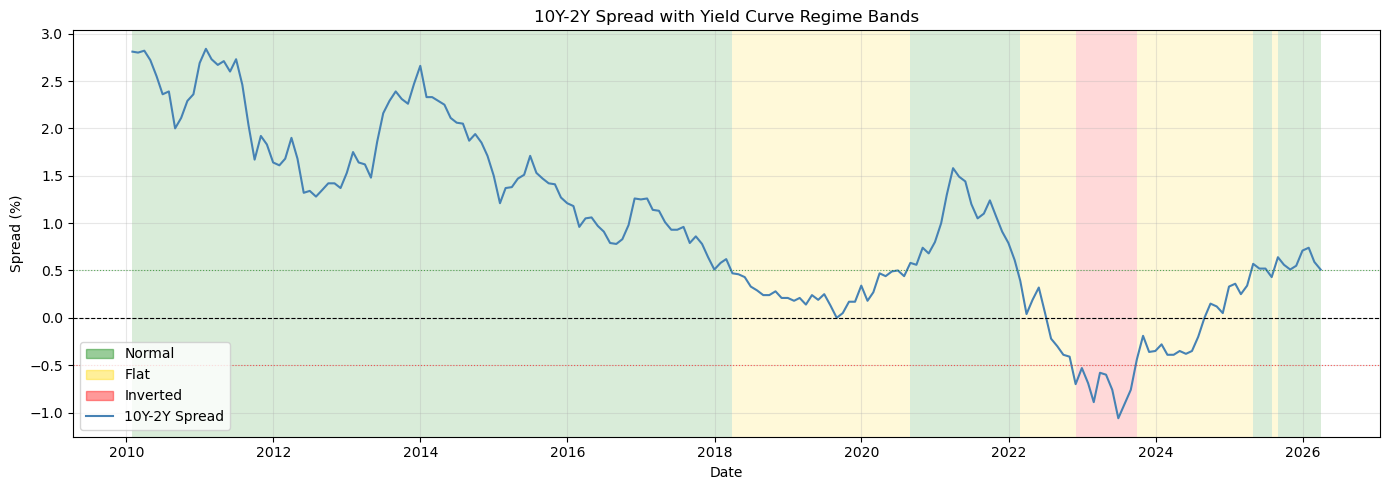

Months per regime:
  Normal    : 127 months (65.1%)
  Flat      : 58 months (29.7%)
  Inverted  : 10 months (5.1%)


In [15]:
main_df = yields_monthly.copy()
main_df['spread_2y10y'] = spread
main_df['regime'] = regimes

REGIME_COLORS = {'Normal': 'green', 'Flat': 'gold', 'Inverted': 'red'}

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(spread.index, spread.values, color='steelblue', linewidth=1.5, label='10Y-2Y Spread')
ax.axhline(0.5, color='green', linestyle=':', linewidth=0.8, alpha=0.6)
ax.axhline(-0.5, color='red', linestyle=':', linewidth=0.8, alpha=0.6)
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)

# draw axvspan bands for each contiguous regime block
regime_series = regimes.dropna()
prev_regime = regime_series.iloc[0]
block_start = regime_series.index[0]
for date, r in regime_series.items():
    if r != prev_regime:
        ax.axvspan(block_start, date, color=REGIME_COLORS[prev_regime], alpha=0.15, linewidth=0)
        block_start = date
        prev_regime = r
ax.axvspan(block_start, regime_series.index[-1], color=REGIME_COLORS[prev_regime], alpha=0.15, linewidth=0)

legend_patches = [Patch(color=REGIME_COLORS[r], alpha=0.4, label=r) for r in ['Normal', 'Flat', 'Inverted']]
ax.legend(handles=legend_patches + [ax.lines[0]], labels=['Normal', 'Flat', 'Inverted', '10Y-2Y Spread'])
ax.set_title('10Y-2Y Spread with Yield Curve Regime Bands')
ax.set_xlabel('Date')
ax.set_ylabel('Spread (%)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

counts = regimes.value_counts().reindex(['Normal', 'Flat', 'Inverted'])
print("Months per regime:")
for r, n in counts.items():
    print(f"  {r:10s}: {n} months ({n / len(regimes) * 100:.1f}%)")

Threshold rationale: The +/-50 bps cutoffs are a defensible but somewhat arbitrary choice. They are wide enough to exclude ambiguous near-zero readings from the "Normal" bucket while keeping the three regimes economically distinct. A sensitivity analysis varying these thresholds (e.g., +/-25 bps or +/-75 bps) could test whether the predictive results in Section 5 are robust to this classification decision.

---

## Section 4: PCA on the Yield Curve

We fit PCA to the standardized yield matrix (195 monthly observations x 10 maturities) and retain three components. Each component maps to a well-known economic concept: the overall level of rates, the slope of the curve, and the curvature of the belly. These three factors are the independent variables in the Section 5 regression models.

In [16]:
# Fit scaler and PCA on training period only to avoid lookahead into the test set
train_mask = yields_monthly.index <= '2019-12-31'

scaler = StandardScaler()
scaler.fit(yields_monthly.loc[train_mask, YIELD_SERIES])
yield_matrix = scaler.transform(yields_monthly[YIELD_SERIES])

pca = PCA(n_components=3)
pca.fit(yield_matrix[np.asarray(train_mask)])
pc_scores = pca.transform(yield_matrix)

pc_scores_df = pd.DataFrame(pc_scores, index=yields_monthly.index,
                            columns=['PC1_Level', 'PC2_Slope', 'PC3_Curvature'])
loadings = pd.DataFrame(pca.components_.T, index=MATURITIES,
                        columns=['PC1_Level', 'PC2_Slope', 'PC3_Curvature'])

# enforce sign conventions so interpretations are consistent
if loadings['PC1_Level'].iloc[0] < 0:
    loadings['PC1_Level'] *= -1
    pc_scores_df['PC1_Level'] *= -1
if loadings['PC2_Slope'].iloc[0] > 0:  # short end should be negative for slope
    loadings['PC2_Slope'] *= -1
    pc_scores_df['PC2_Slope'] *= -1
if loadings['PC3_Curvature'].iloc[0] < 0:  # short end should be positive for curvature
    loadings['PC3_Curvature'] *= -1
    pc_scores_df['PC3_Curvature'] *= -1

evr = pca.explained_variance_ratio_
print(f"Variance explained: PC1={evr[0]:.1%}, PC2={evr[1]:.1%}, PC3={evr[2]:.1%}")
print(f"Cumulative (3 PCs): {evr.sum():.1%}")

Variance explained: PC1=59.2%, PC2=37.7%, PC3=2.8%
Cumulative (3 PCs): 99.7%


### 4.1: Explained Variance

The scree plot quantifies how much of the yield curve's total variation each principal component captures. PC1 dominates because most of the time the entire curve shifts up or down together in response to monetary policy changes. PC2 and PC3 capture the independent slope and curvature dynamics that remain after the level variation is removed.

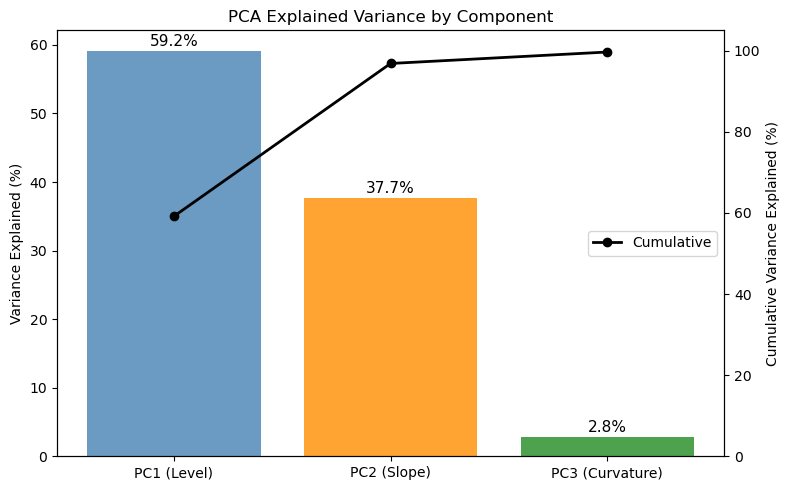

In [17]:
labels = ['PC1 (Level)', 'PC2 (Slope)', 'PC3 (Curvature)']
cumulative = evr.cumsum()

fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

bars = ax1.bar(labels, evr * 100, color=['steelblue', 'darkorange', 'forestgreen'], alpha=0.8)
ax2.plot(labels, cumulative * 100, color='black', marker='o', linewidth=2, label='Cumulative')

for bar, val in zip(bars, evr):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f'{val:.1%}', ha='center', va='bottom', fontsize=11)

ax1.set_ylabel('Variance Explained (%)')
ax2.set_ylabel('Cumulative Variance Explained (%)')
ax2.set_ylim(0, 105)
ax1.set_title('PCA Explained Variance by Component')
ax2.legend(loc='center right')
plt.tight_layout()
plt.show()

### 4.2: Component Loadings

The loadings show how each maturity contributes to each principal component. Interpreting these correctly is the central analytical contribution of the PCA section:

PC1 (Level): Loadings are roughly equal and positive across all maturities. When PC1 is high, the entire yield curve is elevated. This factor captures parallel shifts driven by overall changes in the rate environment, such as Fed tightening or easing cycles.

PC2 (Slope): Loadings are negative at short maturities and positive at long maturities. When PC2 is high, long rates exceed short rates (steep curve). When PC2 is low, the curve is flat or inverted. This factor directly maps to the spread-based regime classification from Section 3 and is the most economically interesting regressor in Section 5.

PC3 (Curvature): Loadings are positive at the short and long ends and negative in the middle. When PC3 is high, the curve is humped and the belly is depressed relative to the wings. This factor captures the independent movement of intermediate maturities, often driven by market expectations about the timing of rate changes.

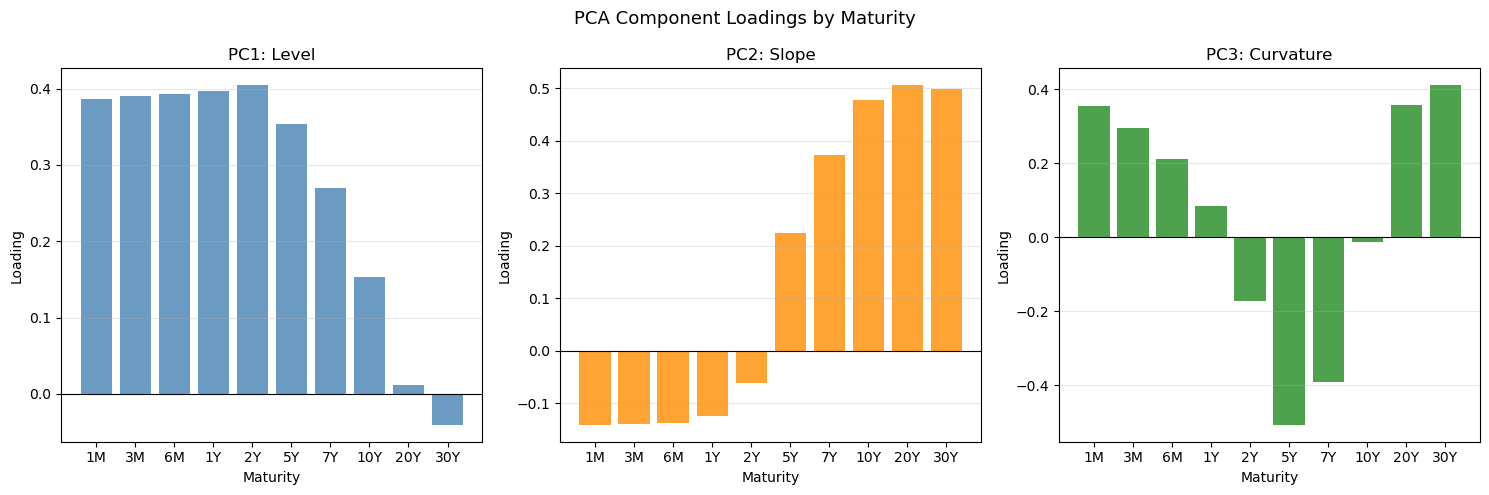

In [18]:
pc_colors = ['steelblue', 'darkorange', 'forestgreen']
pc_titles = ['PC1: Level', 'PC2: Slope', 'PC3: Curvature']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col, color, title in zip(axes, loadings.columns, pc_colors, pc_titles):
    ax.bar(MATURITIES, loadings[col], color=color, alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Maturity')
    ax.set_ylabel('Loading')
    ax.grid(alpha=0.3, axis='y')

fig.suptitle('PCA Component Loadings by Maturity', fontsize=13)
plt.tight_layout()
plt.show()

### 4.3: PC Scores Over Time

Plotting the PC scores as time series connects the PCA decomposition back to the regime analysis from Section 3. PC2 (Slope) is the most informative: it turns sharply negative during curve inversion periods, confirming that this component captures exactly the same signal as the 2Y10Y spread. The alignment between negative PC2 scores and the inversion shading validates the PCA as a richer but fully consistent representation of the yield curve dynamics established earlier.

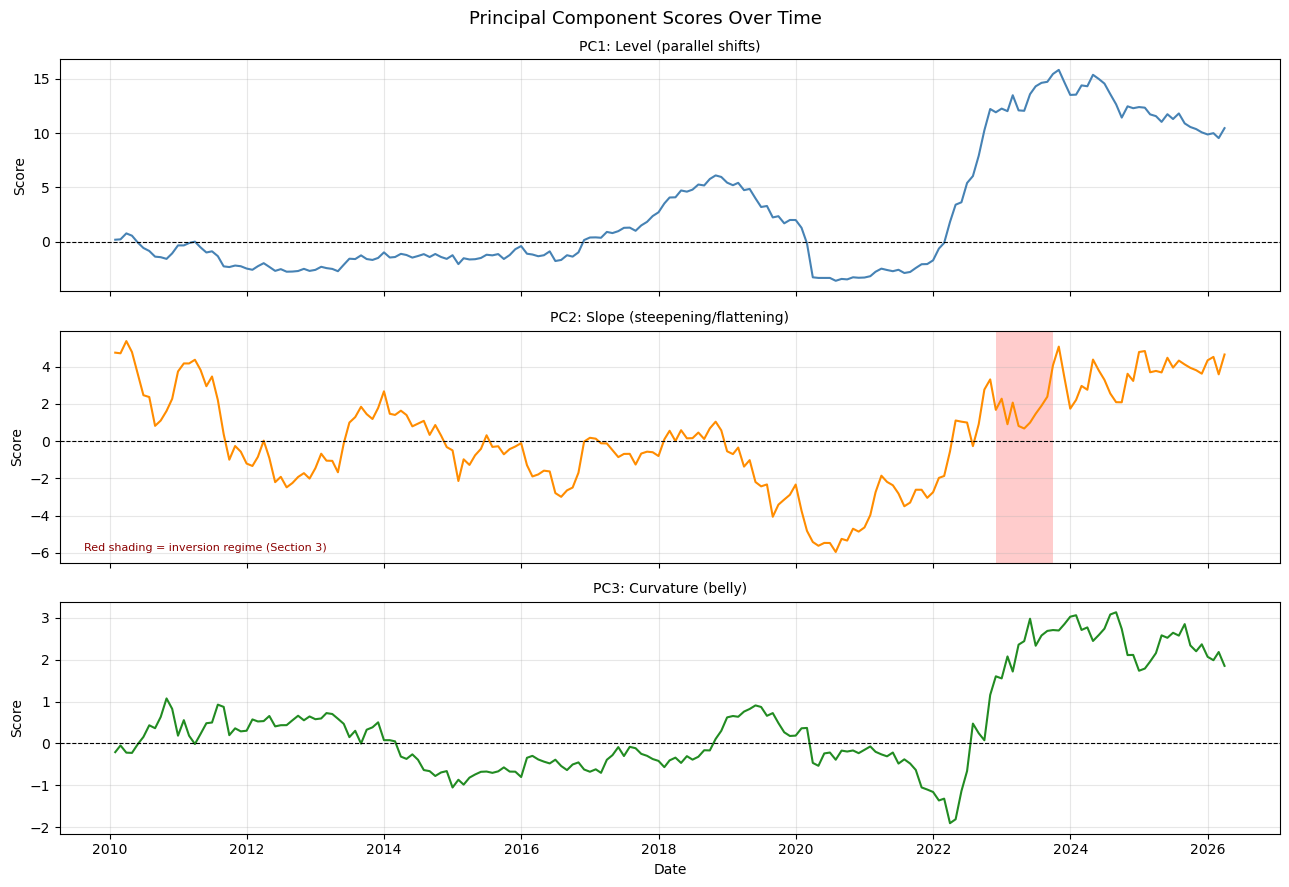

In [19]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
score_titles = ['PC1: Level (parallel shifts)', 'PC2: Slope (steepening/flattening)', 'PC3: Curvature (belly)']

for ax, col, color, title in zip(axes, pc_scores_df.columns, pc_colors, score_titles):
    ax.plot(pc_scores_df.index, pc_scores_df[col], color=color, linewidth=1.5)
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_ylabel('Score')
    ax.set_title(title, fontsize=10)
    ax.grid(alpha=0.3)

# shade inversion periods on PC2 panel to connect back to Section 3 regime labels
inv_mask = regimes == 'Inverted'
block_starts, block_ends = [], []
prev = False
for date, inv in inv_mask.items():
    if inv and not prev:
        block_starts.append(date)
    elif not inv and prev:
        block_ends.append(date)
    prev = inv
if prev:
    block_ends.append(regimes.index[-1])

for s, e in zip(block_starts, block_ends):
    axes[1].axvspan(s, e, color='red', alpha=0.2, linewidth=0)

axes[1].text(0.02, 0.05, 'Red shading = inversion regime (Section 3)',
             transform=axes[1].transAxes, color='darkred', fontsize=8)

axes[-1].set_xlabel('Date')
fig.suptitle('Principal Component Scores Over Time', fontsize=13)
plt.tight_layout()
plt.show()

---

## Section 5: Statistical Modeling and Forecasting

Rolling OLS allows the relationship between yield curve factors and sector returns to evolve over time, which is more realistic than a static regression given changing monetary policy regimes. A static model imposed over the full 2010 to 2026 sample would blend periods with fundamentally different rate structures, masking the regime dynamics this project is designed to study.

All regressors are lagged by one month to avoid lookahead bias. At month t, the model uses PC scores observed at month t-1 to predict returns earned during month t. This ensures the model only uses information that was observable before the return period begins.

In [20]:
X_lagged = sm.add_constant(pc_scores_df.shift(1))
common_idx = X_lagged.dropna().index.intersection(etf_forward_aligned.dropna(how='all').index)
X = X_lagged.loc[common_idx]
Y = etf_forward_aligned.loc[common_idx]

print(f'Regression dataset: {len(X)} monthly observations')
print(f'Date range: {X.index.min().date()} to {X.index.max().date()}')

Regression dataset: 194 monthly observations
Date range: 2010-02-28 to 2026-03-31


### 5.1: Rolling OLS

A 36-month rolling window provides enough observations for stable coefficient estimates while being short enough to capture meaningful time variation in the yield curve to equity return relationship. Each point in the rolling series reflects a regression fit on only the preceding 36 months, allowing the model to adapt as the rate environment changes.

In [21]:
WINDOW = 36

rolling_rsq = {}
rolling_params = {}

for ticker in ETF_TICKERS:
    res = RollingOLS(Y[ticker], X, window=WINDOW).fit()
    rolling_rsq[ticker] = res.rsquared
    rolling_params[ticker] = res.params

print('Rolling OLS fit complete')
avg_rsq = {t: rolling_rsq[t].dropna().mean() for t in ETF_TICKERS}
for t, v in avg_rsq.items():
    print(f'  {t}: mean R^2 = {v:.4f}')

Rolling OLS fit complete
  XLK: mean R^2 = 0.0835
  XLF: mean R^2 = 0.1050
  XLE: mean R^2 = 0.0962
  XLU: mean R^2 = 0.0532
  XLV: mean R^2 = 0.0498
  XLI: mean R^2 = 0.0738
  XLP: mean R^2 = 0.0509
  XLY: mean R^2 = 0.0748


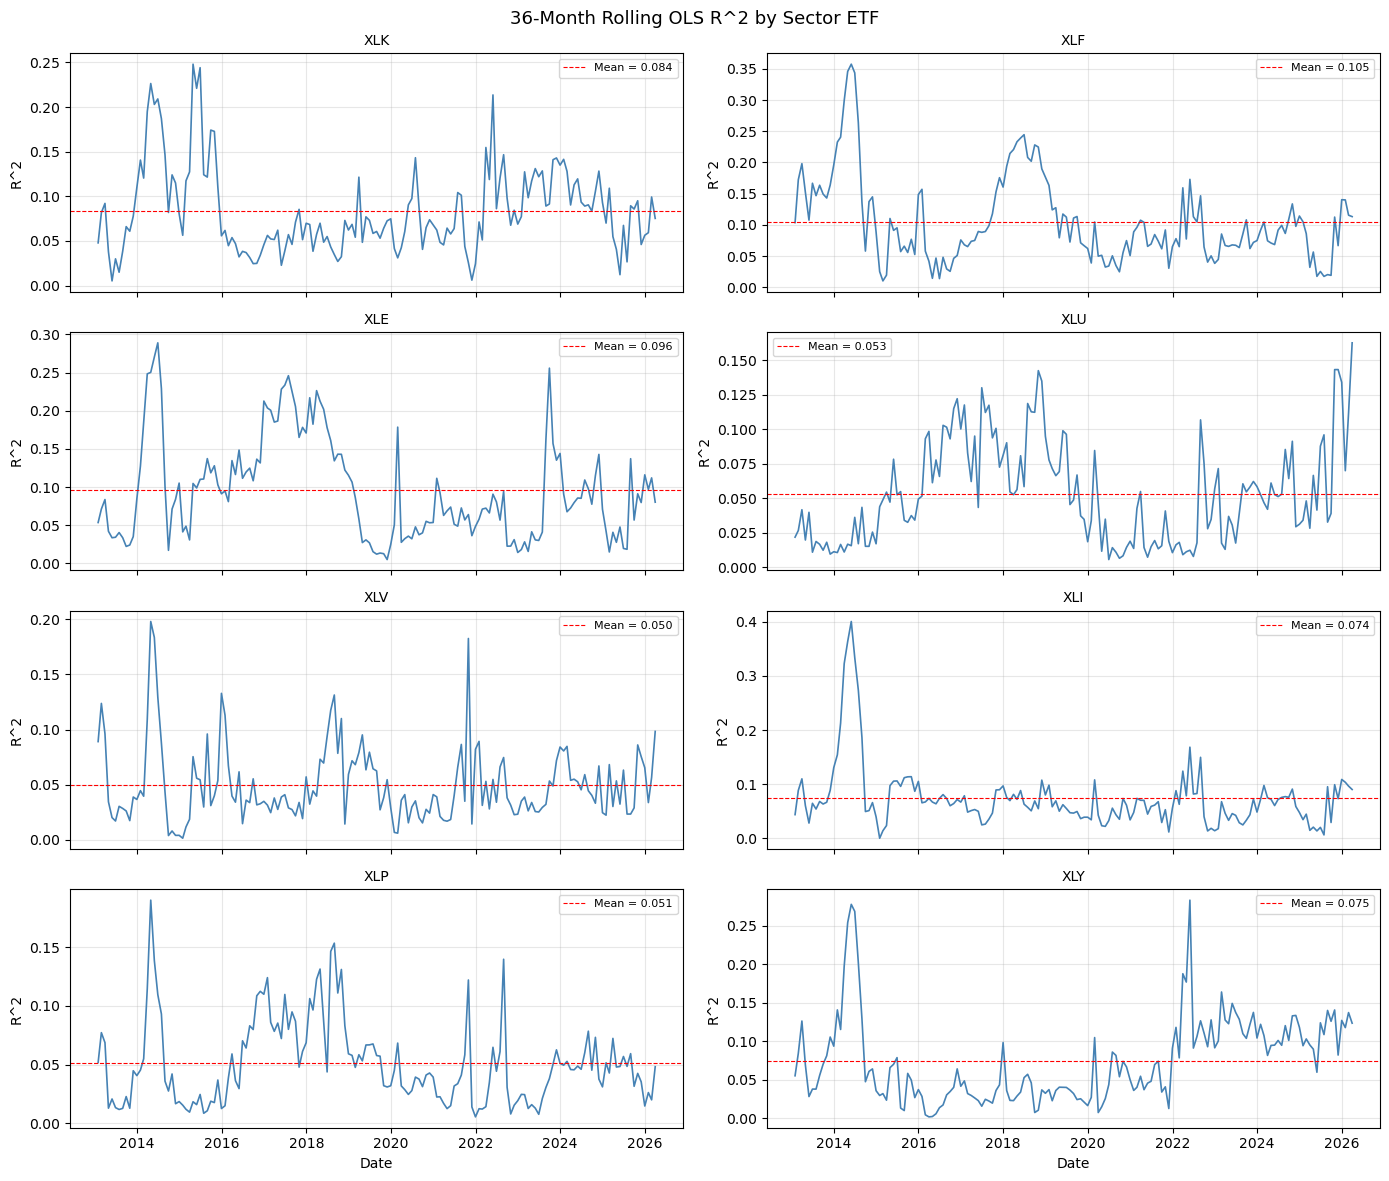

In [22]:
fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharex=True)
for ax, ticker in zip(axes.flat, ETF_TICKERS):
    rsq = rolling_rsq[ticker].dropna()
    ax.plot(rsq.index, rsq, linewidth=1.2, color='steelblue')
    ax.axhline(rsq.mean(), color='red', linestyle='--', linewidth=0.8,
               label=f'Mean = {rsq.mean():.3f}')
    ax.set_title(ticker, fontsize=10)
    ax.set_ylabel('R^2')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('36-Month Rolling OLS R^2 by Sector ETF', fontsize=13)
axes[-1][0].set_xlabel('Date')
axes[-1][1].set_xlabel('Date')
plt.tight_layout()
plt.show()

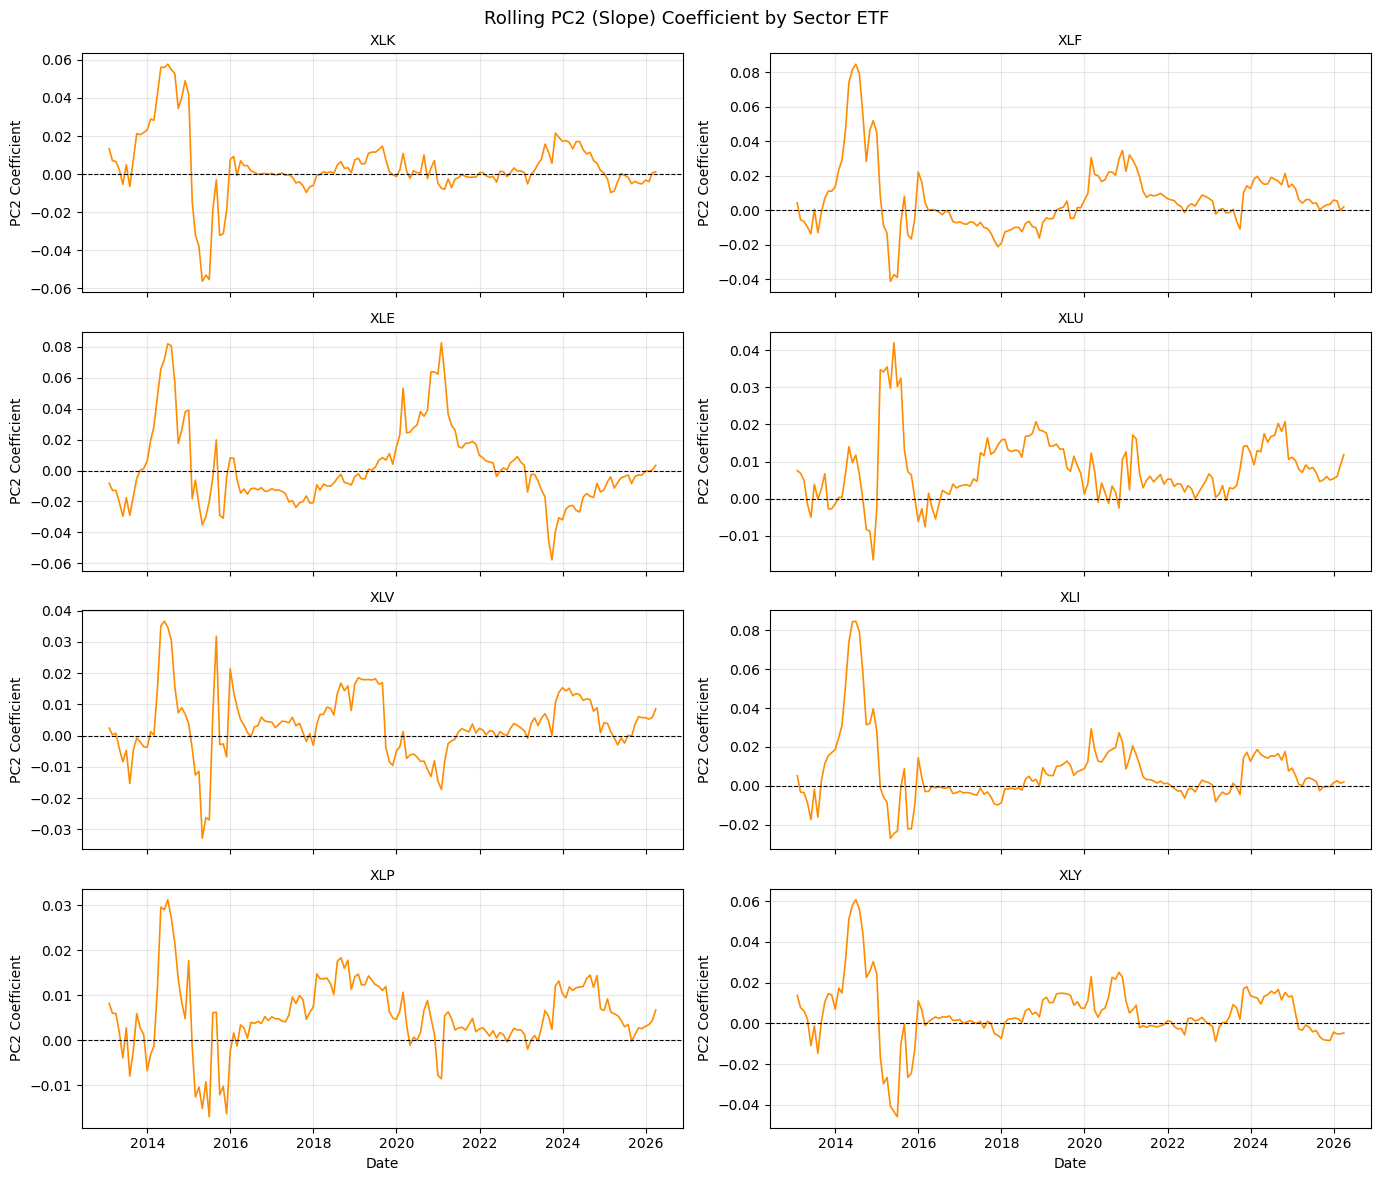

In [23]:
fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharex=True)
for ax, ticker in zip(axes.flat, ETF_TICKERS):
    coef = rolling_params[ticker]['PC2_Slope'].dropna()
    ax.plot(coef.index, coef, linewidth=1.2, color='darkorange')
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(ticker, fontsize=10)
    ax.set_ylabel('PC2 Coefficient')
    ax.grid(alpha=0.3)

fig.suptitle('Rolling PC2 (Slope) Coefficient by Sector ETF', fontsize=13)
axes[-1][0].set_xlabel('Date')
axes[-1][1].set_xlabel('Date')
plt.tight_layout()
plt.show()

In [24]:
# Note: the rolling R^2 at time t reflects a model fit on months t-35 through t, which spans
# multiple regimes. Averaging by regime bucket means 'average window quality when the
# endpoint falls in regime X', not 'model quality when trained entirely within regime X'.
# Section 5.3's explicit regime-conditional regression is the cleaner answer to that question.
rsq_rows = []
for ticker in ETF_TICKERS:
    rsq = rolling_rsq[ticker].dropna()
    row = {'Ticker': ticker, 'Full Sample': rsq.mean()}
    for regime in ['Normal', 'Flat', 'Inverted']:
        regime_idx = rsq.index.intersection(regimes[regimes == regime].index)
        row[regime] = rsq.loc[regime_idx].mean()
    rsq_rows.append(row)

rsq_by_regime = pd.DataFrame(rsq_rows).set_index('Ticker').round(4)
print('Average rolling R\u00b2 by sector and regime (see note above on interpretation):')
rsq_by_regime

Average rolling R² by sector and regime (see note above on interpretation):


,Full Sample,Normal,Flat,Inverted
Ticker,,,,
XLK,0.0835,0.0801,0.0852,0.1044
XLF,0.1050,0.1063,0.1102,0.0636
XLE,0.0962,0.1094,0.0852,0.0412
XLU,0.0532,0.0524,0.0571,0.0378
XLV,0.0498,0.0493,0.0542,0.0292
XLI,0.0738,0.0847,0.0634,0.0341
XLP,0.0509,0.0496,0.0586,0.0184
XLY,0.0748,0.0681,0.0765,0.1258


### 5.2: Train/Test Split

We train a static OLS on January 2010 through December 2019, then evaluate out of sample on January 2020 to present. The test period is intentionally challenging: it spans COVID volatility, the zero interest rate policy period, and the 2022 aggressive hiking cycle. All three represent structural breaks relative to the training sample, making this a conservative and realistic test of the model's predictive power.

In [25]:
TRAIN_END = '2019-12-31'
X_train, X_test = X[X.index <= TRAIN_END], X[X.index > TRAIN_END]
Y_train, Y_test = Y[Y.index <= TRAIN_END], Y[Y.index > TRAIN_END]

oos_rows = []
for ticker in ETF_TICKERS:
    y_tr = Y_train[ticker].dropna()
    res = sm.OLS(y_tr, X_train.loc[y_tr.index]).fit()
    y_te = Y_test[ticker].dropna()
    y_pred = res.predict(X_test.loc[y_te.index])
    oos_rows.append({
        'Ticker': ticker,
        'In-Sample R^2': res.rsquared,
        'OOS RMSE': np.sqrt(mean_squared_error(y_te, y_pred)),
        'OOS MAE': mean_absolute_error(y_te, y_pred)
    })

metrics_df = pd.DataFrame(oos_rows).set_index('Ticker').round(4)
print(f'Train: {X_train.index.min().date()} to {X_train.index.max().date()} ({len(X_train)} months)')
print(f'Test:  {X_test.index.min().date()} to {X_test.index.max().date()} ({len(X_test)} months)')
metrics_df

Train: 2010-02-28 to 2019-12-31 (119 months)
Test:  2020-01-31 to 2026-03-31 (75 months)


,In-Sample R^2,OOS RMSE,OOS MAE
Ticker,,,
XLK,0.0187,0.0623,0.0515
XLF,0.0687,0.0645,0.0497
XLE,0.0350,0.1004,0.0682
XLU,0.0127,0.0538,0.0427
XLV,0.0201,0.0434,0.0363
XLI,0.0224,0.0591,0.0452
XLP,0.0107,0.0414,0.0330
XLY,0.0113,0.0656,0.0499


### 5.3: Regime-Conditional Regression

Rather than relying on the rolling window to implicitly capture regime differences, we explicitly segment the sample by yield curve regime and run a separate static OLS for each regime and sector pair. The key question is whether the PC2 (Slope) coefficient differs meaningfully across regimes.

Note on timing: The regime label assigned to month t uses the spread observed at month t (it is contemporaneous, not lagged). Strictly speaking, the lagged spread (month t−1) would be the information available when predicting month t returns. Because regimes are highly persistent (see the ACF in Section 2.5), this has negligible practical impact, but it is a temporal inconsistency worth noting.

Defensive sectors (XLU, XLV, XLP) are expected to show a negative PC2 coefficient: a steeper curve signals rising rates and growth optimism, which tends to rotate capital toward cyclicals and away from defensive yield proxies. Cyclicals (XLK, XLY, XLE) are expected to show positive PC2 coefficients for the same reason. The PC2 coefficient during inversions is the most economically interesting, since it captures how each sector behaves when the curve is signaling a potential contraction.

In [26]:
regime_rows = []
for regime in ['Normal', 'Flat', 'Inverted']:
    regime_idx = X.index.intersection(main_df.index[main_df['regime'] == regime])
    for ticker in ETF_TICKERS:
        y = Y.loc[regime_idx, ticker].dropna()
        res = sm.OLS(y, X.loc[y.index]).fit()
        regime_rows.append({
            'Regime': regime, 'Ticker': ticker,
            'PC1': res.params['PC1_Level'],
            'PC2 (Slope)': res.params['PC2_Slope'],
            'PC3': res.params['PC3_Curvature'],
            'R^2': res.rsquared,
            'n': int(len(y))
        })

regime_df = pd.DataFrame(regime_rows).set_index(['Regime', 'Ticker']).round(4)
regime_df

PC1  PC2 (Slope)     PC3     R^2    n
Regime   Ticker                                          
Normal   XLK     0.0011      -0.0018  0.0083  0.0359  126
         XLF    -0.0008      -0.0063  0.0128  0.0921  126
         XLE    -0.0003      -0.0063  0.0195  0.0586  126
         XLU    -0.0006       0.0011  0.0033  0.0095  126
         XLV    -0.0026      -0.0004  0.0093  0.0368  126
         XLI    -0.0002      -0.0028  0.0120  0.0388  126
         XLP    -0.0018       0.0008  0.0031  0.0169  126
         XLY    -0.0013      -0.0013  0.0101  0.0229  126
Flat     XLK     0.0027      -0.0101  0.0070  0.0705   58
         XLF     0.0035      -0.0045  0.0045  0.0564   58
         XLE     0.0001       0.0035 -0.0052  0.0071   58
         XLU     0.0050      -0.0053 -0.0073  0.0164   58
         XLV     0.0034      -0.0056 -0.0043  0.0097   58
         XLI     0.0032      -0.0052  0.0014  0.0182   58
         XLP     0.0007      -0.0022  0.0024  0.0123   58
         XLY    -0.0119       0.0093  0.0337  0.0689   58
Inverted XLK    -0.0098      -0.1011 -0.0802  0.9241   10
         XLF    -0.0022      -0.0056  0.0133  0.0377   10
         XLE     0.0176      -0.0117  0.0143  0.2199   10
         XLU    -0.0130      -0.0062  0.0067  0.1177   10
         XLV     0.0095      -0.0297 -0.0287  0.1743   10
         XLI    -0.0223      -0.0206  0.0110  0.4242   10
         XLP     0.0018      -0.0277 -0.0300  0.1306   10
         XLY    -0.0036      -0.1063 -0.0805  0.6631   10

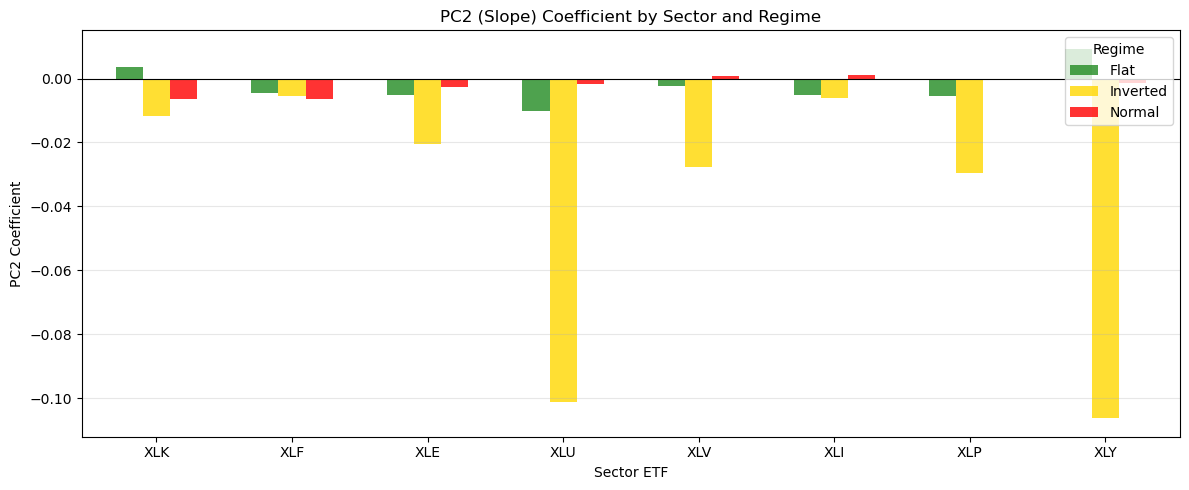

In [27]:
pc2_pivot = regime_df['PC2 (Slope)'].unstack('Ticker')

fig, ax = plt.subplots(figsize=(12, 5))
pc2_pivot.T.plot(kind='bar', ax=ax,
                 color=['forestgreen', 'gold', 'red'], alpha=0.8, width=0.6)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('PC2 (Slope) Coefficient by Sector and Regime')
ax.set_xlabel('Sector ETF')
ax.set_ylabel('PC2 Coefficient')
ax.legend(title='Regime', loc='upper right')
ax.set_xticklabels(ETF_TICKERS, rotation=0)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 5.4: Full Model Summary

The table below consolidates the key model evaluation metrics across all 8 sectors. Rolling average R^2 reflects the average explanatory power over the full sample using the 36-month rolling window. In-sample R^2 and out-of-sample RMSE and MAE come from the train/test static regression in Section 5.2. Together these metrics summarize how well the three yield curve PC factors explain and predict sector return variation across both the training period and the structurally distinct post-2020 test period.

In [28]:
rolling_avg_rsq = pd.Series(
    {t: rolling_rsq[t].dropna().mean() for t in ETF_TICKERS}, name='Rolling Avg R^2'
).round(4)

summary_df = metrics_df.copy()
summary_df.insert(0, 'Rolling Avg R^2', rolling_avg_rsq)
print('Full model evaluation summary:')
summary_df

Full model evaluation summary:


,Rolling Avg R^2,In-Sample R^2,OOS RMSE,OOS MAE
Ticker,,,,
XLK,0.0835,0.0187,0.0623,0.0515
XLF,0.1050,0.0687,0.0645,0.0497
XLE,0.0962,0.0350,0.1004,0.0682
XLU,0.0532,0.0127,0.0538,0.0427
XLV,0.0498,0.0201,0.0434,0.0363
XLI,0.0738,0.0224,0.0591,0.0452
XLP,0.0509,0.0107,0.0414,0.0330
XLY,0.0748,0.0113,0.0656,0.0499


---

## Section 6: Cross-Sectional Rank Model & Information Coefficient

Instead of predicting each sector's absolute return level, we rank all 8 sectors within each month (rank 1 = worst performer, rank 8 = best) and re-run the same rolling OLS on those ranks. This removes broad market beta, which dominates level returns and swamps the yield curve signal, and forces the model to compete purely on sector rotation, which is what yield curve shape actually carries.

The Information Coefficient (IC) measures whether the model consistently identifies which sectors will outperform each month. For each month, we compute the Spearman rank correlation between the model's predicted scores and the actual sector ranks across all 8 ETFs, then average over time. A mean IC significantly above zero, confirmed by its t-statistic, is a stronger and more practically relevant claim than a low level-return R^2.

Note on in-sample vs out-of-sample: The Rolling R^2 (Ranks) reported in the summary table below is the standard in-sample rolling R^2 (each window’s R^2 includes the contemporaneous observation). The IC, by contrast, is computed out-of-sample: fitted ranks use coefficients from the prior period (shifted params), so each prediction is genuinely forward-looking. These two metrics are not directly comparable; the IC is the more honest measure of predictive ability.

Mean IC : 0.0194
t-stat  : 0.58  (|t| > 2 suggests IC is reliably above zero)
IC > 0  : 51.9% of months


/var/folders/1r/bvsymj4d5nn9l_m14n2dkf_00000gn/T/ipykernel_9060/3640674332.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(row[valid], actual[valid])[0]


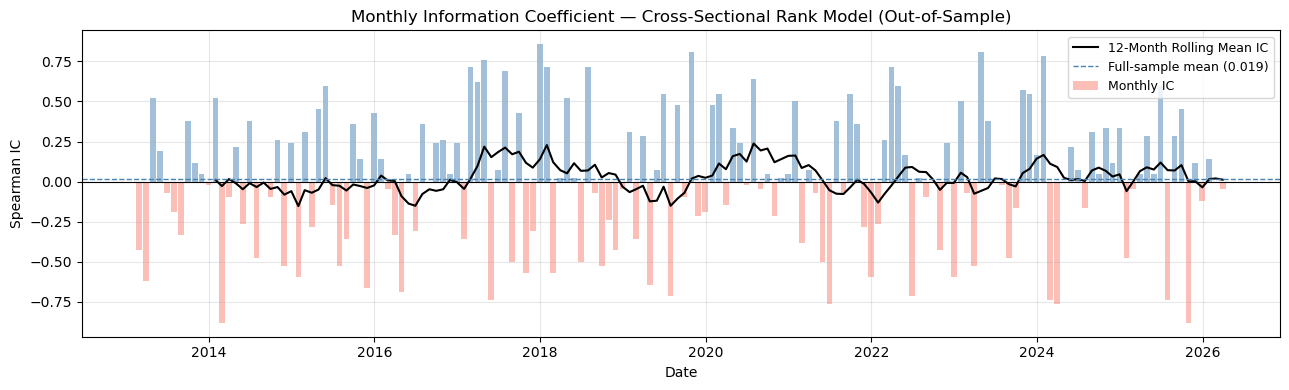

In [29]:
# cross-sectional rank within each month: rank 1 = lowest return, rank 8 = highest
etf_ranks = etf_forward_aligned.rank(axis=1)
Y_ranks = etf_ranks.loc[X.index]

# rolling OLS on ranks: same X, same 36-month window as Section 5.1
rolling_rsq_ranks = {}
rolling_fitted_ranks = {}

for ticker in ETF_TICKERS:
    res = RollingOLS(Y_ranks[ticker], X, window=WINDOW).fit()
    rolling_rsq_ranks[ticker] = res.rsquared
    # use prior period's beta to forecast ranks (true out-of-sample: beta[t-1] predicts rank[t])
    rolling_fitted_ranks[ticker] = (X * res.params.shift(1)).sum(axis=1)

fitted_df = pd.DataFrame(rolling_fitted_ranks)

# IC: for each month, Spearman correlation between model scores and actual ranks across 8 sectors
def monthly_ic(row):
    actual = Y_ranks.loc[row.name]
    valid = ~(row.isna() | actual.isna())
    if valid.sum() < 4:
        return np.nan
    return spearmanr(row[valid], actual[valid])[0]

ic_series = fitted_df.apply(monthly_ic, axis=1).dropna()
mean_ic  = ic_series.mean()
ic_tstat = mean_ic / (ic_series.std() / np.sqrt(len(ic_series)))

print(f"Mean IC : {mean_ic:.4f}")
print(f"t-stat  : {ic_tstat:.2f}  (|t| > 2 suggests IC is reliably above zero)")
print(f"IC > 0  : {(ic_series > 0).mean():.1%} of months")

# plot IC over time with a rolling 12-month average
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(ic_series.index, ic_series, color=np.where(ic_series >= 0, 'steelblue', 'salmon'),
       alpha=0.5, width=25, label='Monthly IC')
ax.plot(ic_series.index, ic_series.rolling(12).mean(), color='black',
        linewidth=1.5, label='12-Month Rolling Mean IC')
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(mean_ic, color='steelblue', linestyle='--', linewidth=1, label=f'Full-sample mean ({mean_ic:.3f})')
ax.set_title('Monthly Information Coefficient — Cross-Sectional Rank Model (Out-of-Sample)')
ax.set_xlabel('Date')
ax.set_ylabel('Spearman IC')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
# Summary: levels R^2 vs rank R^2 per sector, plus overall IC
summary = pd.DataFrame({
    'Rolling R^2 (Levels)': {t: rolling_rsq[t].dropna().mean()       for t in ETF_TICKERS},
    'Rolling R^2 (Ranks)':  {t: rolling_rsq_ranks[t].dropna().mean() for t in ETF_TICKERS},
}).round(4)

print('Per-sector rolling R^2 comparison and overall IC:')
display(summary)
print(f"\nOverall Mean IC: {mean_ic:.4f}  |  t-stat: {ic_tstat:.2f}  |  IC > 0: {(ic_series > 0).mean():.1%} of months")
print("\nInterpretation: IC measures cross-sectional rank accuracy each month, independent of market direction.")
print("A t-stat above 2 indicates the model identifies sector rotation with statistical reliability.")

Per-sector rolling R^2 comparison and overall IC:


,Rolling R^2 (Levels),Rolling R^2 (Ranks)
XLK,0.0835,0.1015
XLF,0.1050,0.1444
XLE,0.0962,0.0943
XLU,0.0532,0.0552
XLV,0.0498,0.0819
XLI,0.0738,0.0630
XLP,0.0509,0.0785
XLY,0.0748,0.1292



Overall Mean IC: 0.0194  |  t-stat: 0.58  |  IC > 0: 51.9% of months

Interpretation: IC measures cross-sectional rank accuracy each month, independent of market direction.
A t-stat above 2 indicates the model identifies sector rotation with statistical reliability.
